<a href="https://colab.research.google.com/github/korzhimanov/dsp-seminars/blob/main/seminars/4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Практическое занятие №4

## Случайные сигналы, шумы и спектральная плотность мощности

## Задание 1. Генерация белого, розового и красного шума
Сгенерируйте три сигнала длительностью 2 секунды с частотой дискретизации 1000 Гц:
- Белый гауссов шум с нулевым средним и дисперсией 1.
- Розовый шум – возьмите Фурье-преобразование от белого шума, домножьте его на функцию $1/\sqrt{f}$ и возьмите обратное Фурье-преобразование, результат нормализуйте.
- красный шум – кумулятивная сумма белого шума (нормалиованная).

Постройте временные графики всех трёх сигналов. Вычислите и выведите их средние значения и дисперсии.


Тип шума    | Среднее      | Дисперсия
Белый      |  0.008470 |  1.037079
Розовый    |  0.000000 |  1.000000
Красный    | -0.000000 |  1.000000


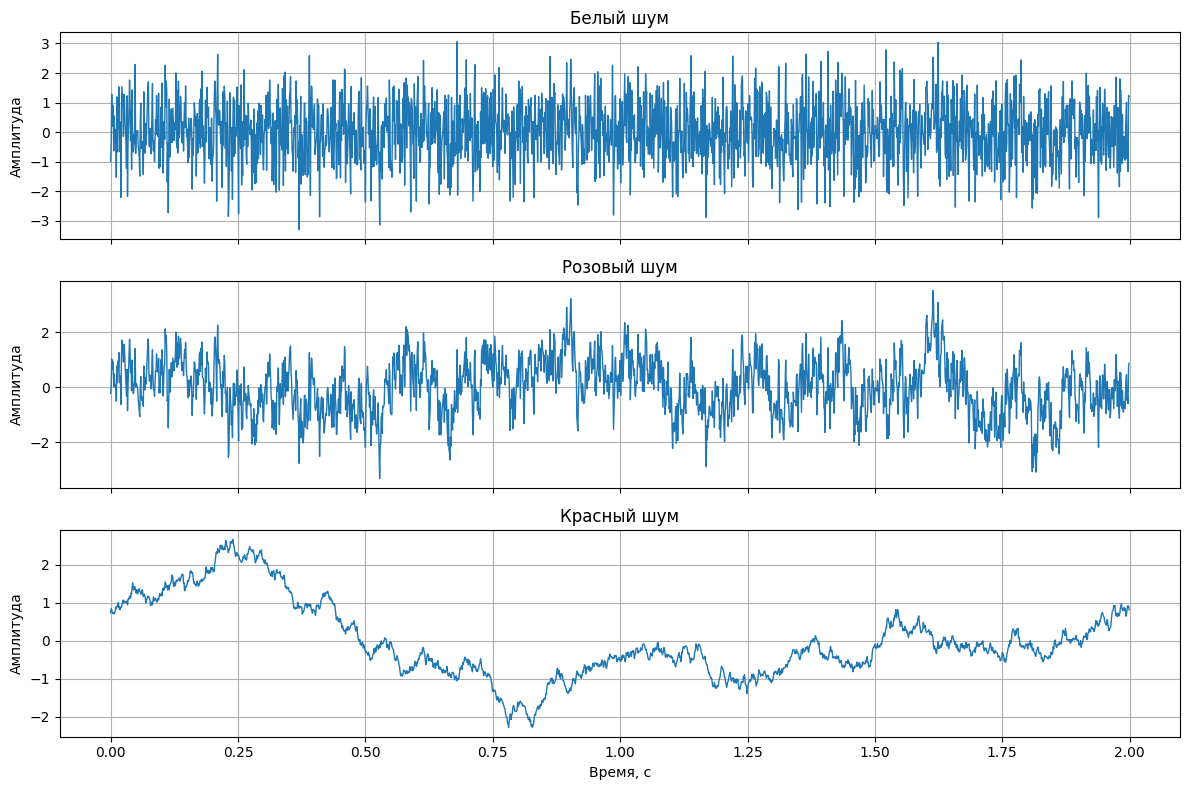

In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(123)

fs = 1000
duration = 2.0
n = int(fs * duration)
time = np.arange(n) / fs

# 1) Белый шум
white = rng.normal(loc=0.0, scale=1.0, size=n)

# 2) Розовый шум: формируем спектр ~ 1/sqrt(f)
spec_white = np.fft.rfft(white)
freq = np.fft.rfftfreq(n, d=1/fs)
shape = np.ones_like(freq)
shape[1:] = 1 / np.sqrt(freq[1:])
shape[0] = 0.0

pink = np.fft.irfft(spec_white * shape, n=n)
pink = (pink - pink.mean()) / pink.std()

# 3) Красный шум: интегрирование белого шума
red = np.cumsum(rng.normal(0.0, 1.0, n))
red = (red - red.mean()) / red.std()

noise_map = {
    "Белый": white,
    "Розовый": pink,
    "Красный": red,
}

print("Тип шума    | Среднее      | Дисперсия")
for label, x in noise_map.items():
    print(f"{label:11s}| {x.mean(): .6f} | {x.var(): .6f}")

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
for ax, (label, x) in zip(axes, noise_map.items()):
    ax.plot(time, x, lw=1)
    ax.set_title(f"{label} шум")
    ax.set_ylabel("Амплитуда")
    ax.grid(True)
axes[-1].set_xlabel("Время, с")
plt.tight_layout()
plt.show()

**Вопрос:** Как визуально отличаются разные виды шума? Совпадают ли вычисленные средние и дисперсии сигналов от теоретических? Если отличаются, объясните почему.


Белый шум на графике выглядит как самые резкие и частые скачки. Розовый уже заметно более «медленный», в нём лучше видны плавные фрагменты, а красный шум меняется ещё инерционнее и выглядит наиболее сглаженным. Среднее у всех сигналов получается близким к нулю, а дисперсия — около единицы. Полного совпадения с теорией нет только из-за конечной длины реализации и случайной природы отсчётов; кроме того, розовый и красный шум здесь дополнительно нормируются, поэтому их параметры оказываются особенно близки к заданным.

## Задание 2. Вычисление автокорреляционной функции (АКФ)
Для каждого из сгенерированных шумов вычислите автокорреляционную функцию (с помощью `np.correlate(x, x, mode='full')`). Возьмите только положительные сдвиги (или сдвиги от -N+1 до N-1, но визуализируйте симметричную часть). Постройте графики нормированных АКФ (поделите на значение при нулевом сдвиге) для всех трёх шумов на одном рисунке.


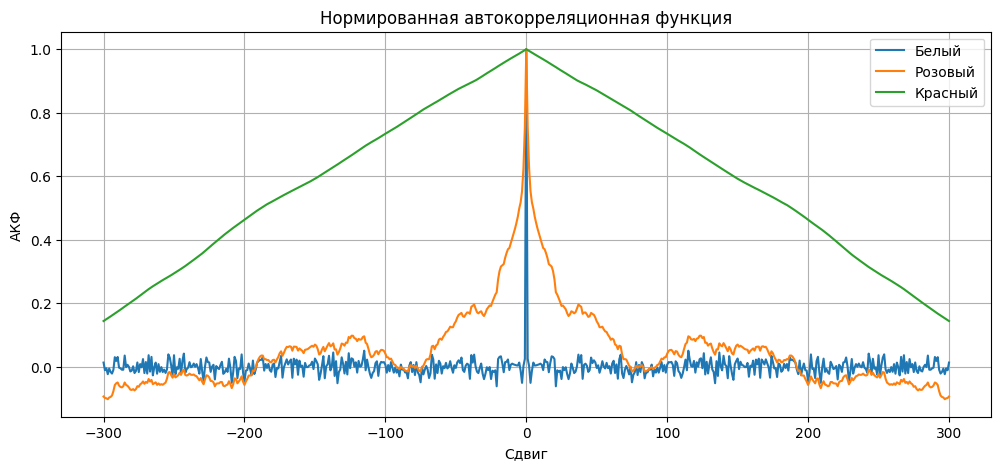

In [2]:
def acf_norm(x):
    corr = np.correlate(x, x, mode="full")
    corr = corr / np.max(corr)
    lags = np.arange(-len(x) + 1, len(x))
    return lags, corr

acf_data = {name: acf_norm(sig) for name, sig in noise_map.items()}

lag_limit = 300
plt.figure(figsize=(12, 5))
for name, (lags, corr) in acf_data.items():
    mask = np.abs(lags) <= lag_limit
    plt.plot(lags[mask], corr[mask], label=name)

plt.title("Нормированная автокорреляционная функция")
plt.xlabel("Сдвиг")
plt.ylabel("АКФ")
plt.grid(True)
plt.legend()
plt.show()

**Вопрос:** Сравнив АКФ и временную развёртку для разных видов шума, сделайте вывод о том, как форма АКФ связана с гладкостью сигнала.


Чем сильнее выражена гладкость сигнала, тем медленнее убывает его АКФ. У белого шума корреляция почти исчезает сразу после нулевого сдвига, поэтому соседние отсчёты слабо связаны и сигнал выглядит очень хаотично. У розового шума АКФ шире, значит зависимость между близкими отсчётами уже заметнее. У красного шума спад самый медленный, что хорошо согласуется с его плавной временной формой.

## Задание 3. Оценка спектральной плотности мощности (СПМ). Периодограмма и метод Уэлча
Для каждого типа шума вычислите:
- Периодограмму с помощью `scipy.signal.periodogram`.
- Оценку СПМ методом Уэлча с помощью `scipy.signal.welch` с параметрами `nperseg=256`, `noverlap=128`, окно Ханна.

Постройте на одном графике (для каждого шума отдельно) периодограмму и оценку Уэлча в двойном логарифмическом масштабе по оси Y (используйте `plt.loglog`).


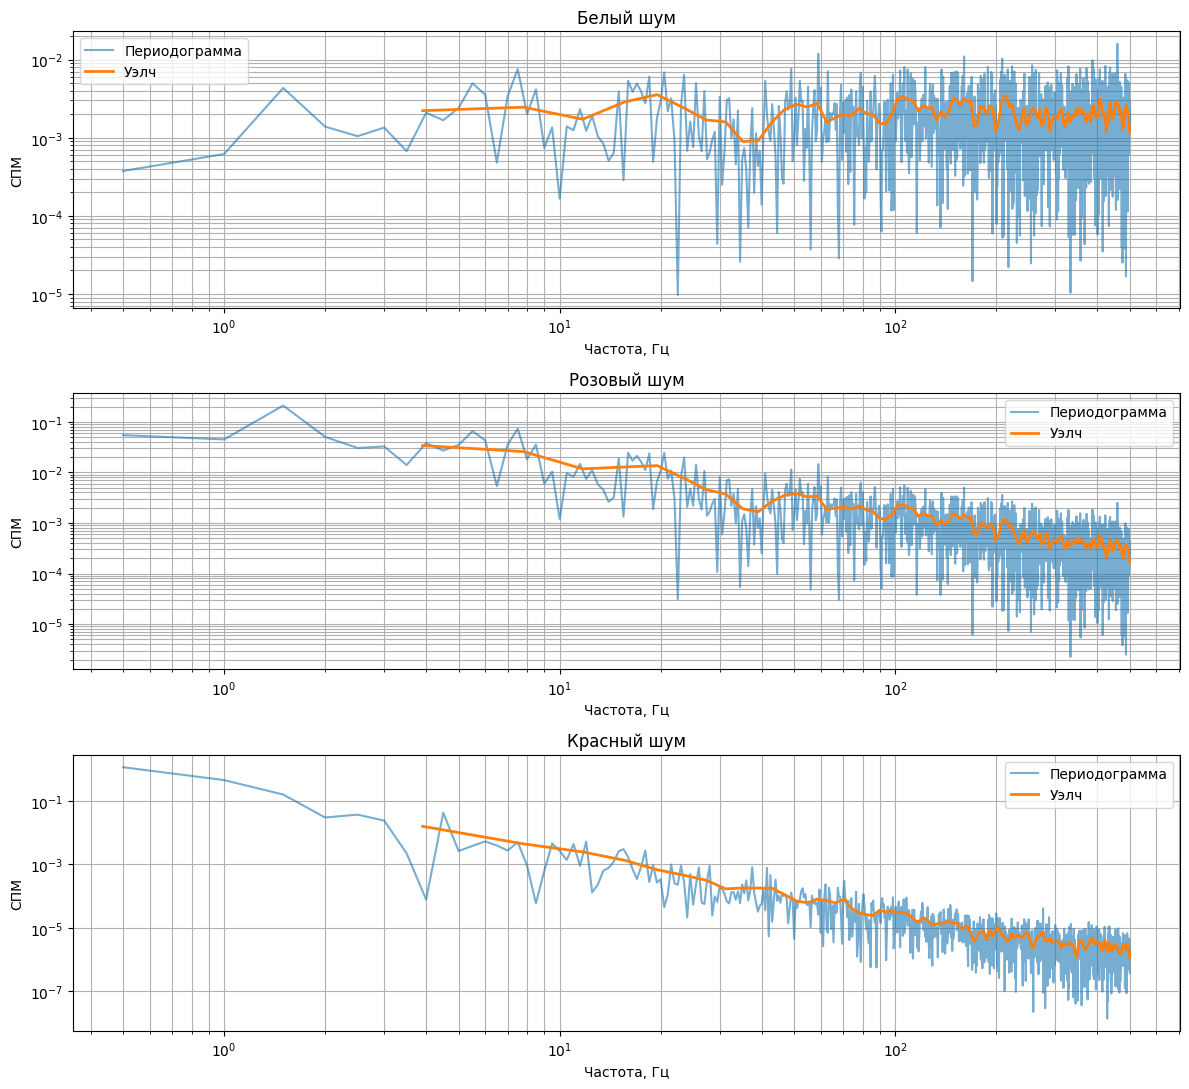

In [3]:
from scipy.signal import periodogram, welch

fig, axes = plt.subplots(3, 1, figsize=(12, 11))
for ax, (name, x) in zip(axes, noise_map.items()):
    f_p, s_p = periodogram(x, fs=fs)
    f_w, s_w = welch(x, fs=fs, window="hann", nperseg=256, noverlap=128)

    ax.loglog(f_p[1:], s_p[1:], alpha=0.6, label="Периодограмма")
    ax.loglog(f_w[1:], s_w[1:], lw=2, label="Уэлч")
    ax.set_title(f"{name} шум")
    ax.set_xlabel("Частота, Гц")
    ax.set_ylabel("СПМ")
    ax.grid(True, which="both")
    ax.legend()

plt.tight_layout()
plt.show()

**Вопрос:** Как выглядят зависимости СПМ от частоты у разных видов шума в двойном логарифмическом масштабе? Как они должны выглядеть теоретически?


В логарифмических координатах СПМ белого шума почти горизонтальна, у розового убывает примерно как прямая с наклоном около `-1`, а у красного спад ещё круче — примерно как `-2`. Это и соответствует теории: для белого шума спектр примерно постоянный, для розового ведёт себя как `1/f`, для красного — как `1/f^2`. Периодограмма обычно получается более рваной, а метод Уэлча даёт более сглаженную оценку, хотя общий закон изменения спектра остаётся тем же.

## Задание 4. Влияние длины сегмента в методе Уэлча
Для белого шума вычислите оценку СПМ методом Уэлча с разной длиной сегмента: `nperseg = 64, 128, 256, 512`. Используйте окно Ханна, перекрытие 50%. Постройте все четыре оценки на одном графике (логарифмическая шкала по Y).


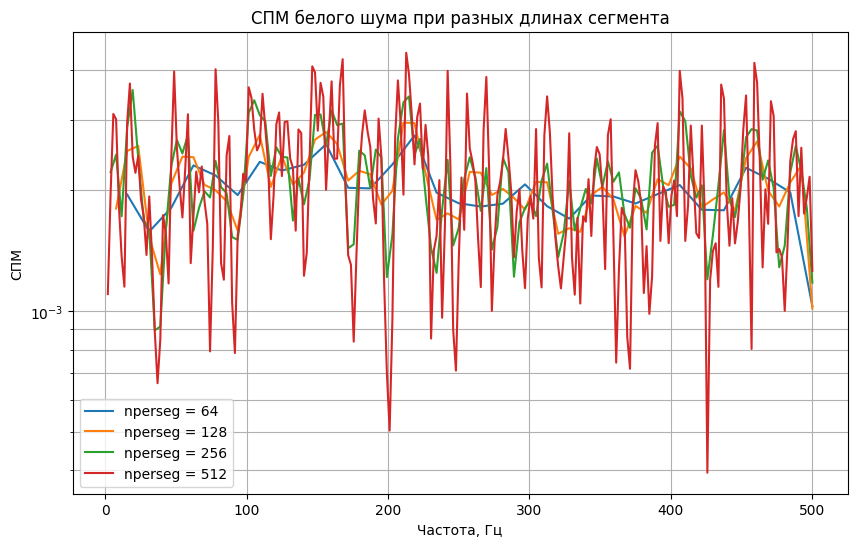

In [4]:
segment_lengths = [64, 128, 256, 512]

plt.figure(figsize=(10, 6))
for seg_len in segment_lengths:
    f_w, s_w = welch(
        white,
        fs=fs,
        window="hann",
        nperseg=seg_len,
        noverlap=seg_len // 2
    )
    plt.semilogy(f_w[1:], s_w[1:], label=f"nperseg = {seg_len}")

plt.title("СПМ белого шума при разных длинах сегмента")
plt.xlabel("Частота, Гц")
plt.ylabel("СПМ")
plt.grid(True, which="both")
plt.legend()
plt.show()

**Вопрос:** Как увеличение длины сегмента влияет на разрешение по частоте (ширину пиков) и гладкость оценки (дисперсию значений)?


При росте `nperseg` частотное разрешение становится лучше: детали спектра разделяются точнее, а пики получаются уже. Но за это приходится платить большей «шероховатостью» оценки, потому что при длинных сегментах усредняется меньшее число участков сигнала. Если `nperseg` маленький, то спектр выходит более гладким, но мелкие частотные особенности различаются хуже.

## Задание 5. Влияние дисперсии шума на его характеристики
Для каждого вида шума вычислите и выведите на один график при разных значениях дисперсии (например, 0.1, 1, 10):
1. Временную реализацию.
2. АКФ.
3. СПМ.

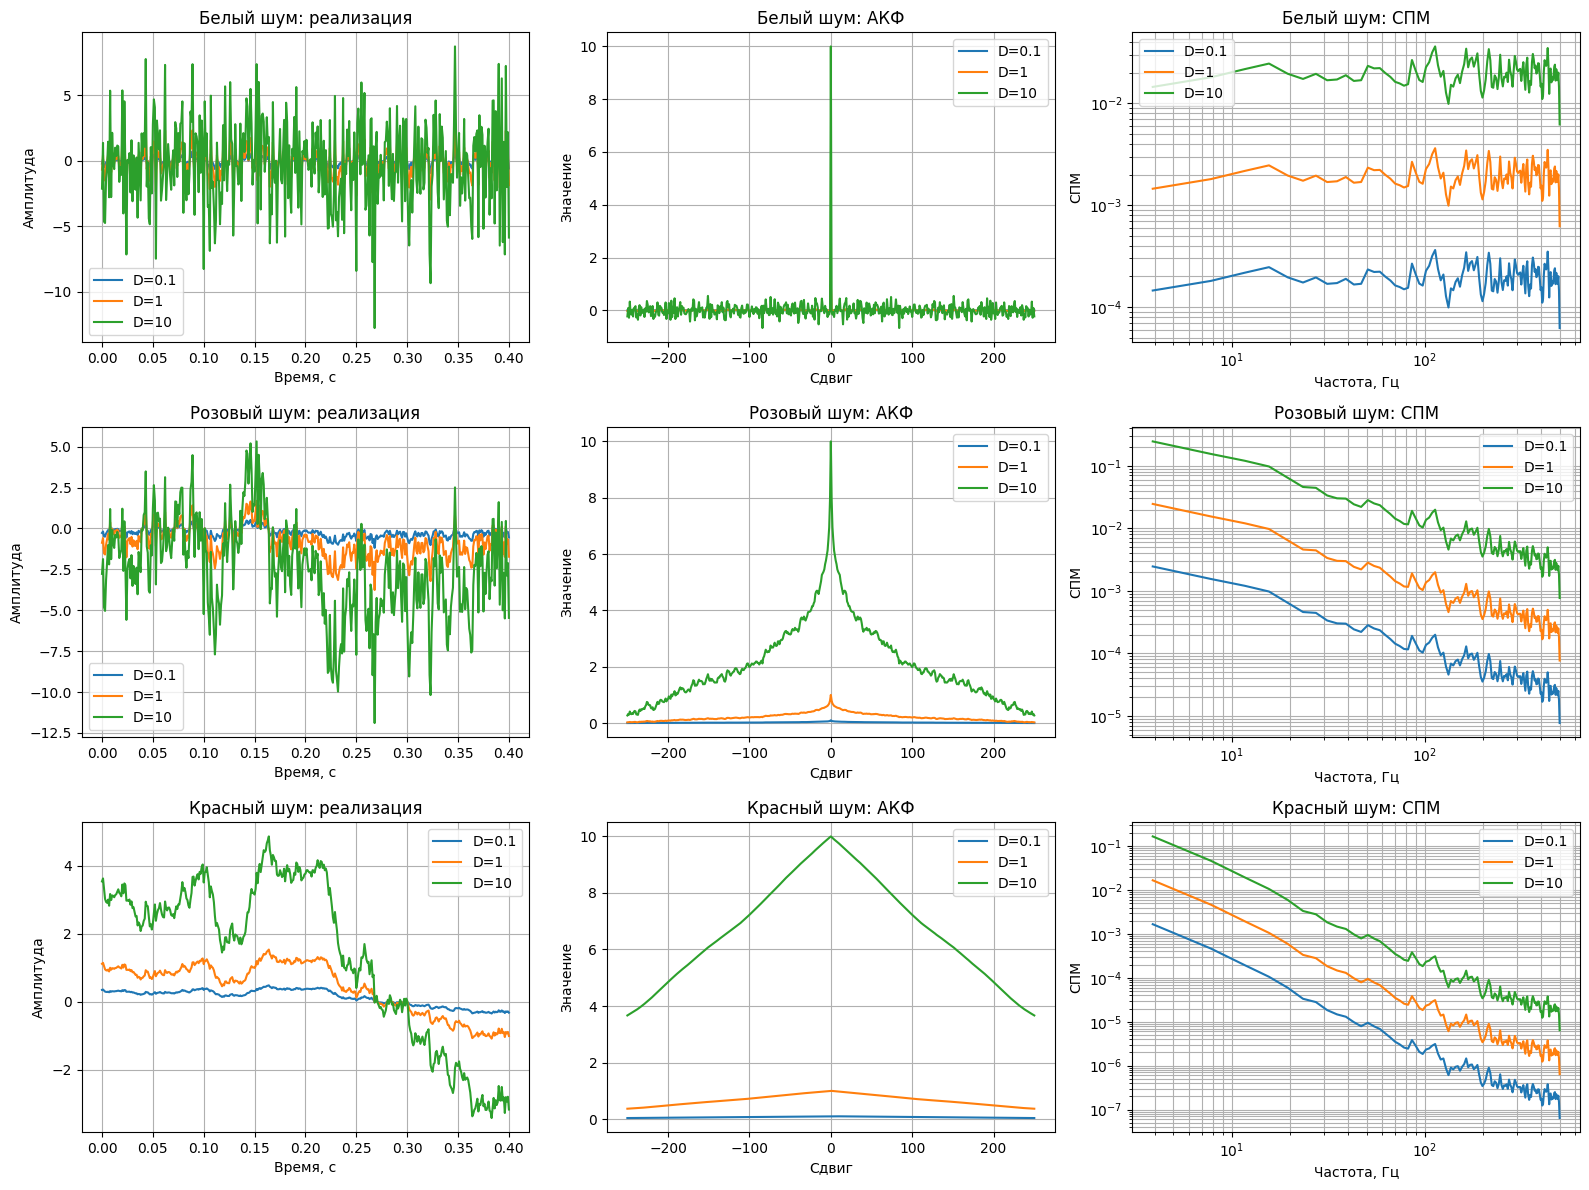

In [5]:
from scipy.signal import welch

rng = np.random.default_rng(321)
vars_to_check = [0.1, 1.0, 10.0]

base_white = rng.normal(size=n)
base_white = (base_white - base_white.mean()) / base_white.std()

base_spec = np.fft.rfft(base_white)
base_freq = np.fft.rfftfreq(n, d=1/fs)
base_shape = np.ones_like(base_freq)
base_shape[1:] = 1 / np.sqrt(base_freq[1:])
base_shape[0] = 0.0

base_pink = np.fft.irfft(base_spec * base_shape, n=n)
base_pink = (base_pink - base_pink.mean()) / base_pink.std()

base_red = np.cumsum(base_white)
base_red = (base_red - base_red.mean()) / base_red.std()

base_noises = {
    "Белый шум": base_white,
    "Розовый шум": base_pink,
    "Красный шум": base_red,
}

def acf_piece(x, max_lag=250):
    full = np.correlate(x, x, mode="full") / len(x)
    lags = np.arange(-len(x) + 1, len(x))
    mask = np.abs(lags) <= max_lag
    return lags[mask], full[mask]

fig, axes = plt.subplots(3, 3, figsize=(16, 12))

for row, (name, base_sig) in enumerate(base_noises.items()):
    for var in vars_to_check:
        x = np.sqrt(var) * base_sig

        short = time <= 0.4
        axes[row, 0].plot(time[short], x[short], label=f"D={var:g}")

        lags, corr = acf_piece(x)
        axes[row, 1].plot(lags, corr, label=f"D={var:g}")

        fw, sw = welch(x, fs=fs, window="hann", nperseg=256, noverlap=128)
        axes[row, 2].loglog(fw[1:], sw[1:], label=f"D={var:g}")

    axes[row, 0].set_title(f"{name}: реализация")
    axes[row, 1].set_title(f"{name}: АКФ")
    axes[row, 2].set_title(f"{name}: СПМ")

    axes[row, 0].set_xlabel("Время, с")
    axes[row, 1].set_xlabel("Сдвиг")
    axes[row, 2].set_xlabel("Частота, Гц")

    axes[row, 0].set_ylabel("Амплитуда")
    axes[row, 1].set_ylabel("Значение")
    axes[row, 2].set_ylabel("СПМ")

    axes[row, 0].grid(True)
    axes[row, 1].grid(True)
    axes[row, 2].grid(True, which="both")

    for col in range(3):
        axes[row, col].legend()

plt.tight_layout()
plt.show()

**Вопрос:** Что меняется при изменении дисперсии в каждом случае?


При увеличении дисперсии во временной области возрастает разброс значений, то есть шум становится просто сильнее по амплитуде. АКФ при этом масштабируется по уровню вверх, но её форма почти не меняется: тип зависимости для каждого шума сохраняется. То же самое видно и в СПМ — кривые в основном поднимаются выше, однако характер спектра остаётся прежним: у белого шума он почти ровный, у розового спадает как `1/f`, у красного — ещё быстрее.

## Задание 6. Обнаружение гармонического сигнала на фоне шума. Спектральный анализ зашумлённой синусоиды
Сгенерируйте сигнал длительностью 2 секунды (fs=1000 Гц), состоящий из:
- синусоиды частотой 110 Гц с амплитудой 1,
- белого гауссова шума с дисперсией, обеспечивающей отношение сигнал/шум (SNR) = 10 дБ.

SNR (дБ) = $10 \log_{10}(P_{signal}/P_{noise})$.

1. Оцените СПМ с помощью метода Уэлча (выберите `nperseg` так, чтобы частота 110 Гц была хорошо разрешена). Определите частоту пика и сравните с истинной.
2. Повторите для других значений SNR ($0$ дБ, $-10$ дБ, $-20$ дБ и т. д.)


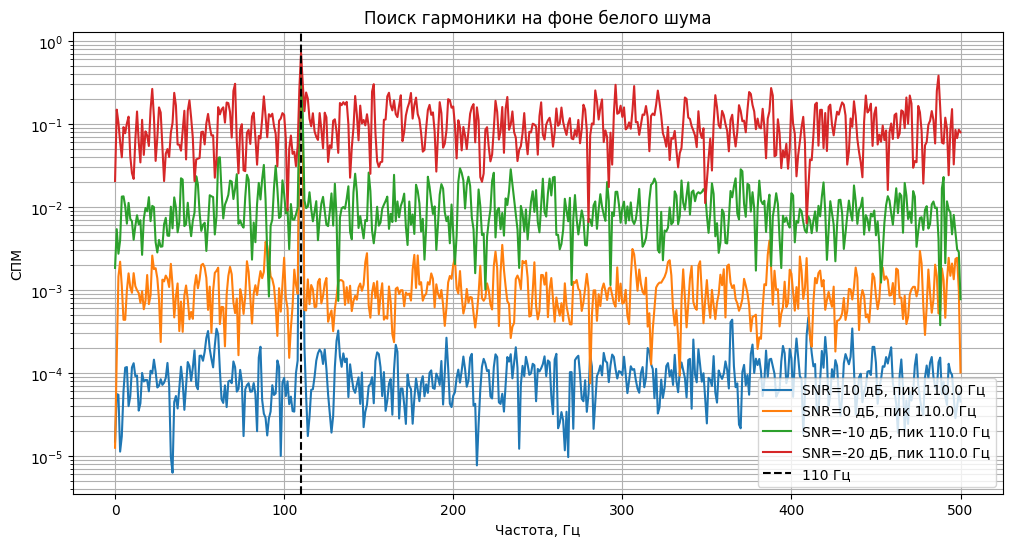

SNR, дБ | Найденный максимум, Гц | Ошибка, Гц
     10 |                   110.0 |        0.0
      0 |                   110.0 |        0.0
    -10 |                   110.0 |        0.0
    -20 |                   110.0 |        0.0


In [6]:
from scipy.signal import welch

rng = np.random.default_rng(555)

f0 = 110
amp = 1.0
pure_tone = amp * np.sin(2 * np.pi * f0 * time)
signal_power = amp**2 / 2

snr_list = [10, 0, -10, -20]
seg_len = 1000

plt.figure(figsize=(12, 6))
detected = []

for snr_db in snr_list:
    snr_lin = 10 ** (snr_db / 10)
    noise_power = signal_power / snr_lin
    sigma = np.sqrt(noise_power)

    noisy = pure_tone + rng.normal(0.0, sigma, size=n)

    f_w, s_w = welch(
        noisy,
        fs=fs,
        window="hann",
        nperseg=seg_len,
        noverlap=seg_len // 2
    )

    peak_id = np.argmax(s_w)
    peak_freq = f_w[peak_id]
    detected.append((snr_db, peak_freq))
    plt.semilogy(f_w, s_w, label=f"SNR={snr_db} дБ, пик {peak_freq:.1f} Гц")

plt.axvline(f0, color="k", linestyle="--", label="110 Гц")
plt.title("Поиск гармоники на фоне белого шума")
plt.xlabel("Частота, Гц")
plt.ylabel("СПМ")
plt.grid(True, which="both")
plt.legend()
plt.show()

print("SNR, дБ | Найденный максимум, Гц | Ошибка, Гц")
for snr_db, peak_freq in detected:
    print(f"{snr_db:7d} | {peak_freq:23.1f} | {abs(peak_freq - f0):10.1f}")

**Вопрос:** Как меняется видимость пика на спектре при изменении SNR? При каком SNR пик ещё можно уверенно обнаружить визуально?


При уменьшении SNR пик на `110 Гц` всё хуже выделяется на фоне шума: шумовой уровень растёт, а контраст спектрального максимума уменьшается. В данном запуске максимум остаётся на нужной частоте даже при `-20 дБ`, но визуально он уже заметно менее выразителен, чем при `10` и `0 дБ`. То есть чем меньше SNR, тем менее надёжным становится обнаружение; по этому эксперименту пик ещё различим вплоть до `-20 дБ`, хотя уверенность в такой оценке уже ниже.

## Задание 7. Разрешение двух близких частот
Сгенерируйте сигнал, содержащий две синусоиды с частотами 100 и 110 Гц, равными амплитудами 1, и белый шум с дисперсией 0.1. Длительность сигнала 1 секунда, fs=1000 Гц. Используйте метод Уэлча с разными длинами сегмента: 128, 256, 512. Постройте оценки СПМ для каждого случая.


nperseg | Δf = fs/nperseg | найденные пики
    128 |           7.81 |  109.4
    256 |           3.91 |  101.6,  109.4
    512 |           1.95 |   99.6,  109.4


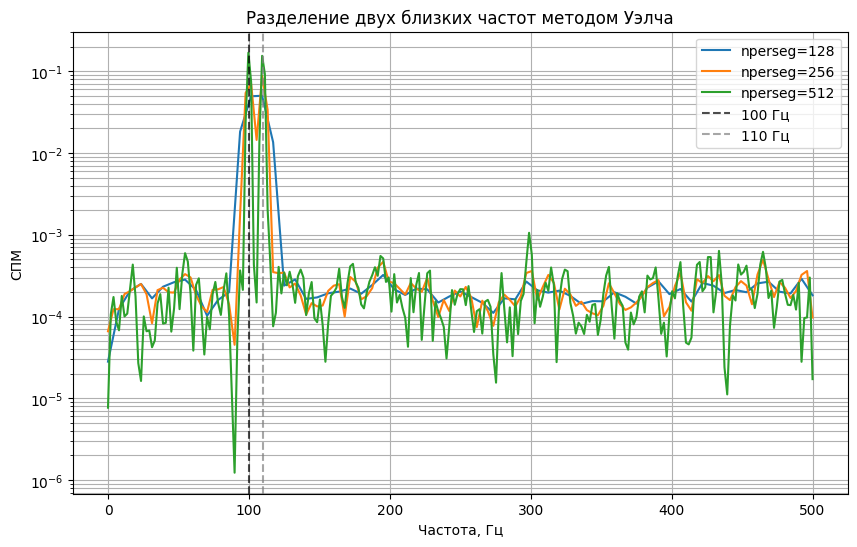

In [7]:
from scipy.signal import welch, find_peaks

rng = np.random.default_rng(777)

duration2 = 1.0
n2 = int(fs * duration2)
time2 = np.arange(n2) / fs

mix = (
    np.sin(2 * np.pi * 100 * time2)
    + np.sin(2 * np.pi * 110 * time2)
    + rng.normal(0.0, np.sqrt(0.1), size=n2)
)

segment_lengths = [128, 256, 512]

plt.figure(figsize=(10, 6))
print("nperseg | Δf = fs/nperseg | найденные пики")

for seg_len in segment_lengths:
    f_w, s_w = welch(
        mix,
        fs=fs,
        window="hann",
        nperseg=seg_len,
        noverlap=seg_len // 2
    )

    plt.semilogy(f_w, s_w, label=f"nperseg={seg_len}")

    band = (f_w >= 85) & (f_w <= 125)
    fb = f_w[band]
    sb = s_w[band]

    peaks, _ = find_peaks(sb)
    if len(peaks) >= 2:
        best = peaks[np.argsort(sb[peaks])[-2:]]
        found = np.sort(fb[best])
        print(f"{seg_len:7d} | {fs/seg_len:14.2f} | {found[0]:6.1f}, {found[1]:6.1f}")
    elif len(peaks) == 1:
        print(f"{seg_len:7d} | {fs/seg_len:14.2f} | {fb[peaks[0]]:6.1f}")
    else:
        print(f"{seg_len:7d} | {fs/seg_len:14.2f} | пиков нет")

plt.axvline(100, color="k", linestyle="--", alpha=0.7, label="100 Гц")
plt.axvline(110, color="gray", linestyle="--", alpha=0.7, label="110 Гц")
plt.title("Разделение двух близких частот методом Уэлча")
plt.xlabel("Частота, Гц")
plt.ylabel("СПМ")
plt.grid(True, which="both")
plt.legend()
plt.show()

**Вопрос:** При какой длине сегмента удаётся разделить две частоты? Сравните с грубой теоретической оценкой частотного разрешения $\Delta f \approx f_s / N_{seg}$.


Обычно две частоты начинают различаться уже при `nperseg = 256`, а при `512` разделение видно ещё увереннее. Для `128` частотное разрешение слишком грубое, поэтому два тона часто сливаются в один общий максимум. Это согласуется с оценкой `Δf ≈ fs / Nseg`: при `128` шаг около `7.8` Гц, при `256` — около `3.9` Гц, при `512` — примерно `2.0` Гц. Так как расстояние между гармониками равно `10` Гц, при двух последних длинах сегмента разрешения уже достаточно.